## Convert midi file into pandas dataframe
*same method also works with mido tracks or list of midi messages stored as dictionaries*

In [491]:
import pandas as pd
import mido

# can't iterate directly on midi file
# because it converts ticks to seconds
midi_file = mido.MidiFile('test.mid')
df = pd.DataFrame([
    # create a list of dictionaries which can be interpreted by pandas
    message.dict() for message in midi_file.tracks[0] if not message.is_meta
])


## Wrangle dataframe

In [492]:
import numpy as np
from sklearn.impute import KNNImputer


# create a category type which enumarates labels in user defined order
type_names = ['note_on', 'note_off', 'control_change']
cat_type = pd.CategoricalDtype(type_names, ordered=True)
# create a new series with the category codes in new variable
wrangled_df = df
wrangled_df['type_codes'] = df['type'].astype(cat_type).cat.codes

# create a new series with shifted codes to use next code
# as current code and predict future
wrangled_df = wrangled_df.drop(['type', 'channel'], axis=1)
wrangled_df = pd.concat(
    # TODO check if it makes sense to use imputer 
    # instead of simple value replacement
    [wrangled_df, wrangled_df.shift(-1).add_prefix('next_')], axis=1
).drop(wrangled_df.tail(1).index)

imputer = KNNImputer(n_neighbors=2)
imputed_array = imputer.fit_transform(wrangled_df)
imputed_df = pd.DataFrame(imputed_array, columns=wrangled_df.columns).astype('int')

imputed_df



,time,note,velocity,control,value,type_codes,next_time,next_note,next_velocity,next_control,next_value,next_type_codes
0,6841,72,10,42,95,0,660,72,0,23,64,1
1,660,72,0,42,32,1,837,58,74,42,32,0
2,837,58,74,20,64,0,253,58,0,20,64,1
3,253,58,0,32,63,1,1310,72,34,10,32,0
4,1310,72,34,10,32,0,310,72,0,10,33,1
...,...,...,...,...,...,...,...,...,...,...,...,...
529,58,60,0,21,64,2,0,64,0,21,63,2
530,0,63,16,21,63,2,610,66,17,21,64,2
531,610,63,14,21,64,2,0,63,16,21,63,2
532,0,69,0,21,63,2,301,63,27,21,64,2


In [493]:
wrangled_df.to_csv('test.csv')


## Create actual training data tables

In [494]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# take column to use as target for predictions
target = imputed_df['next_type_codes']


## Train KNN model for msg type parameter and test for accuracy
*KNN does support multioutput classification (not regression) but it's accuracy evaluation method does not*

In [495]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
# import SimpleImputer to replace NaN because not accepted in KNN
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

# test different settings
for n_neighbors in neighbors_settings:
    type_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    type_knn.fit(X_train, y_train)
    training_accuracy.append(type_knn.score(X_train, y_train))
    test_accuracy.append(type_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
type_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
type_knn.fit(X_train, y_train)

type_knn.predict(X_test).astype('int')


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

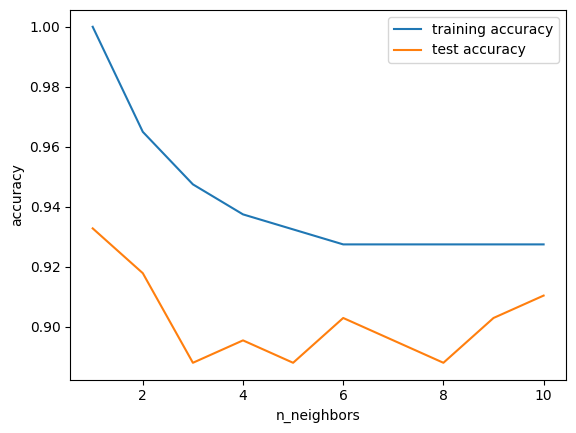

In [496]:
# plotting
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (Note value)

In [497]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data['next_type_codes'] = imputed_df['next_type_codes']
# take column to use as target for predictions
target = imputed_df['next_note']


## Train KNN model for note number parameter and test for accuracy

In [498]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    note_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    note_knn.fit(X_train, y_train)
    training_accuracy.append(note_knn.score(X_train, y_train))
    test_accuracy.append(note_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
note_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
note_knn.fit(X_train, y_train)

note_knn.predict(X_test).astype('int')


array([68, 64, 64, 64, 64, 64, 64, 69, 63, 64, 64, 64, 63, 64, 64, 64, 64,
       64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 66, 64, 64, 64, 64, 63,
       58, 71, 64, 64, 64, 64, 66, 64, 68, 64, 64, 64, 64, 64, 64, 64, 66,
       64, 64, 64, 64, 64, 64, 66, 64, 64, 64, 64, 58, 64, 61, 64, 64, 58,
       64, 64, 64, 64, 62, 64, 64, 64, 66, 64, 64, 61, 64, 66, 64, 64, 64,
       64, 64, 64, 66, 63, 64, 64, 64, 64, 64, 64, 66, 64, 64, 64, 64, 68,
       64, 63, 64, 64, 64, 64, 66, 64, 68, 63, 63, 64, 63, 67, 64, 64, 64,
       64, 64, 64, 72, 58, 64, 69, 64, 64, 68, 64, 64, 64, 64, 64])

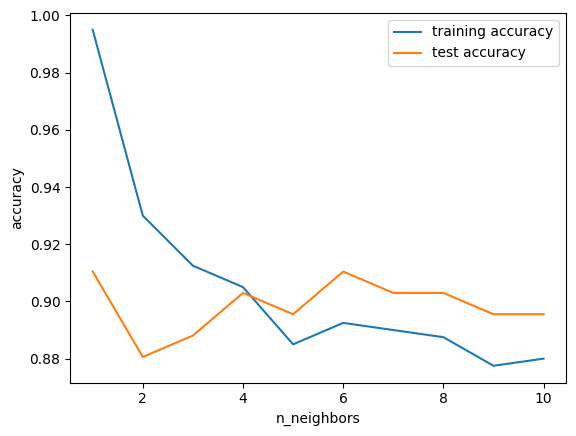

In [499]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (Note velocity)

In [500]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data[['next_type_codes', 'next_note']] = imputed_df[['next_type_codes', 'next_note']]
# take column to use as target for predictions
target = imputed_df['next_velocity']


## Train KNN model for note velocity parameter and test for accuracy

In [501]:
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    vel_knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    vel_knn.fit(X_train, y_train)
    training_accuracy.append(vel_knn.score(X_train, y_train))
    test_accuracy.append(vel_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
vel_knn = KNeighborsRegressor(n_neighbors=highest_score_index)
vel_knn.fit(X_train, y_train)

vel_knn.predict(X_test).astype('int')


array([ 0,  0,  0,  0, 41,  0,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  4, 27,  0, 41,  0,  0, 17, 27,
        0,  0, 41, 27,  0, 17,  0,  0, 41,  0,  0,  0,  0,  0,  0, 41,  0,
        0,  0,  0,  0, 39,  0,  0,  0, 27,  0,  0,  0, 41,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 41,  0,  0,  0,  0,
       41,  0,  0,  0,  0, 16,  0,  0,  0, 41,  0,  0,  0,  0,  0,  0,  0,
       41,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 37,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 27,  0])

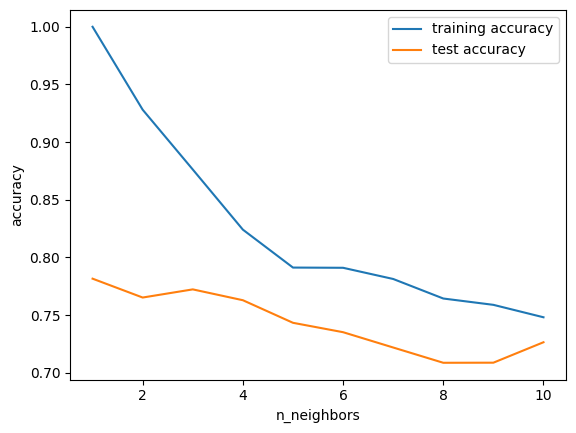

In [502]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (cc number)

In [503]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data['next_type_codes'] = imputed_df['next_type_codes']
# take column to use as target for predictions
target = imputed_df['next_control']


## Train KNN model for note number parameter and test for accuracy

In [504]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    control_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    control_knn.fit(X_train, y_train)
    training_accuracy.append(control_knn.score(X_train, y_train))
    test_accuracy.append(control_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
control_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
control_knn.fit(X_train, y_train)

control_knn.predict(X_test).astype('int')


array([21, 25, 21, 25,  1,  1, 21, 21, 21, 21,  1, 26,  1, 10, 21, 21, 25,
       20,  1,  1, 21, 21, 10,  1, 21, 25, 25, 21, 21, 21,  1, 21, 21, 21,
       20, 21, 26, 25, 21,  1, 21, 21, 21, 25, 21, 21,  1,  1,  1, 21, 21,
       21, 21,  1,  1,  1, 21,  1,  1, 21, 10, 21, 25, 25, 21, 21,  1, 26,
       25, 21, 21, 21,  1, 21, 21, 21,  1, 21, 21, 26,  1,  1, 21, 10, 21,
       21, 21, 21, 10,  1,  1, 20, 21,  1,  1, 25, 21, 21, 21, 21, 21, 25,
        1,  1, 21, 21, 21, 26, 26,  1, 10, 21, 25,  1, 25, 21, 20,  1, 21,
       21, 21, 21,  1,  1, 21,  1, 25,  1, 23, 21,  1, 21,  1,  1])

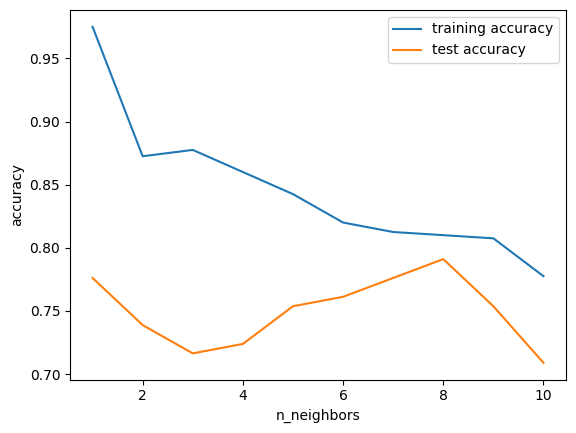

In [505]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (cc number)

In [ ]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data[['next_type_codes', 'next_control']] = imputed_df[['next_type_codes', 'next_control']]
# take column to use as target for predictions
target = imputed_df['next_value']


## Train KNN model for note number parameter and test for accuracy

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    value_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    value_knn.fit(X_train, y_train)
    training_accuracy.append(value_knn.score(X_train, y_train))
    test_accuracy.append(value_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
value_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
value_knn.fit(X_train, y_train)

value_knn.predict(X_test).astype('int')


array([ 64,  63,  64,  68,  32,  64,  64,   5,  64,  64, 110,  63, 122,
        64,  97, 120,  13,  65,  64,  63,  64,  32, 104,  64,  63,  61,
        54,  65,  64,  47, 116, 100,  64,  65,  64,  64,  64,  61,   7,
        63,  63, 110,  64,  64,  33,  63,  64,  26,  64,  63,  64,  64,
        64,  63,  89,  66,  63,  63,  64,  46,  64,  76,  64,  64,  64,
        63,  64,  32,  64,  64,  39,  65,  64,  94,  63,  64,  65,  63,
        64,  63,  57, 125, 116,  64,  64, 116,  62,  64,  82,  51,  64,
       127,  63,  64,  63,  92,  64,  64,  65,  65,  64,  46,  63,  33,
        63,  32,  30,  64,  63,  63,  64,  64,  63,  30,  63,  61,  16,
        64,  63,  64,  64,  42,  32,  64,  64,  10,  64,  32, 113,  63,
        63,  65,  62,  63])

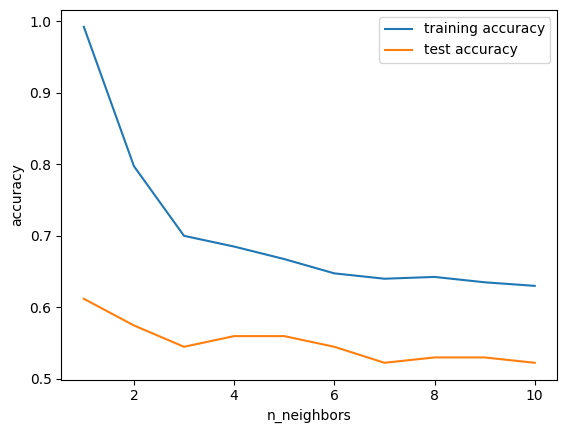

In [ ]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (time)

In [ ]:
# exclude second half of columns ('next_' values)
data = imputed_df.drop('next_time', axis=1)
# take column to use as target for predictions
target = imputed_df['next_time']


## Train KNN model for note number parameter and test for accuracy

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    time_knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    time_knn.fit(X_train, y_train)
    training_accuracy.append(time_knn.score(X_train, y_train))
    test_accuracy.append(time_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
time_knn = KNeighborsRegressor(n_neighbors=highest_score_index)
time_knn.fit(X_train, y_train)

time_knn.predict(X_test).astype('int')


array([  0,   1,  31,  31,   1, 296,  31,   0,   1,   0,   1,  31,  23,
         1,   0,   0,  31,  31,   1, 741, 317,   1,  31,   1,   0,   0,
         0,  27,  31,   1, 452,   0,   1,   5,   0,   0,   0,   0,   1,
         0,   1,   0,   0,  31,   0, 153,   0,   0,   0,   0,   0,   2,
        83,   0,   0,   1, 185, 250, 741,   0, 719, 153,  31,   0,  31,
         1,   1,   0,   1,   1,   0,   0,  31, 120, 296,   8,   9,  26,
       594,   6,  31, 104,  31,   1,   0,   8,   0,   5,   4, 106,   1,
         0,  29,   8,   0,  31,   1,   0,  26,   0,   1,  83, 296,   1,
       104,   9,   0,   0,   0,   0, 323,   6,   0,   1,  83,  26,   0,
        31,   0,  31,  31, 351,   1,   0,   0,  38,   0,  83,  83,  31,
        31,   1,  31,   1])

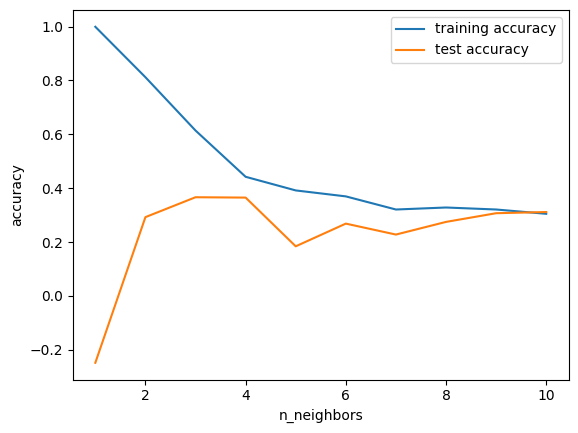

In [ ]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()
